In [2]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
# Globalny motyw — raz, na początku notebooka
sns.set_theme(style='whitegrid', palette='muted')
# Dataset tips — restauracja, 244 rachunki (znany z W09)
tips = sns.load_dataset('tips')
print(f"Tips dataset: {tips.shape[0]} wierszy × {tips.shape[1]} kolumn")
print(f"Kolumny: {list(tips.columns)}")
tips.head(3)

Tips dataset: 244 wierszy × 7 kolumn
Kolumny: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


## Ćw 1

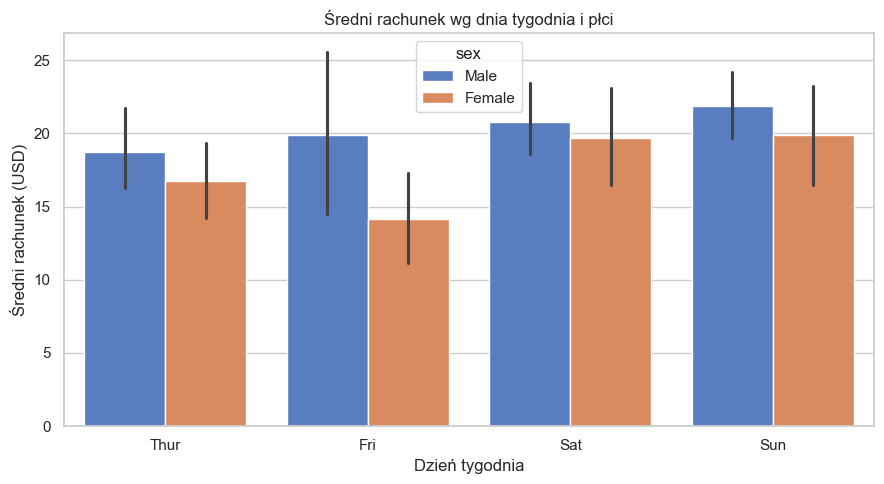

Zapisano: barplot_dzien_plec.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
data=tips,
x='day',
y='total_bill',
hue='sex',
ax=ax,
palette='muted',
errorbar=('ci', 95), # 95% CI = przedział ufności średniej
)
ax.set_title('Średni rachunek wg dnia tygodnia i płci')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Średni rachunek (USD)')
plt.tight_layout()
plt.savefig('barplot_dzien_plec.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: barplot_dzien_plec.png")


# Zad 1.2

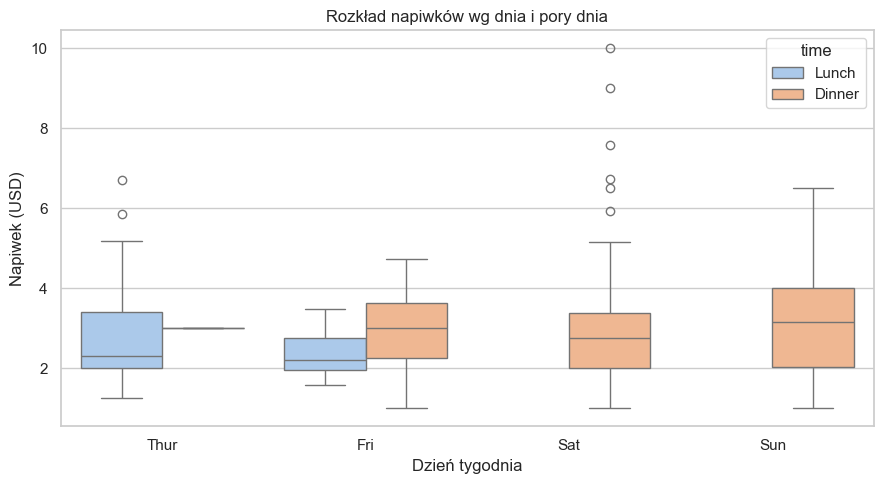

Zapisano boxplot_napiwki.png


In [4]:
fig, ax = plt.subplots(figsize=(9,5))

sns.boxplot(
    data = tips,
    x='day',
    y='tip',
    hue='time',
    ax=ax,
    palette='pastel',
)
ax.set_title('Rozkład napiwków wg dnia i pory dnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Napiwek (USD)')

plt.tight_layout()
plt.savefig('boxplot_napiwki.png', dpi=150, bbox_inches='tight',
 facecolor='white')
plt.show()
plt.close()
print("Zapisano boxplot_napiwki.png")

# Zad 1.3

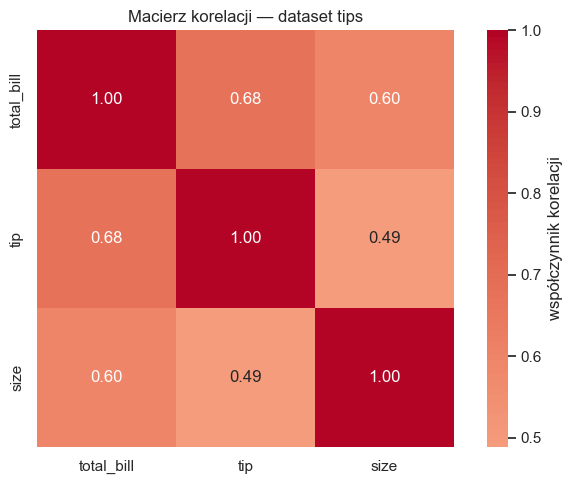

Zapisano: heatmap_korelacja.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = tips.select_dtypes('number').corr()
sns.heatmap(
   corr,
   annot=True, 
   fmt='.2f', 
   cmap='coolwarm', 
center=0, 
ax=ax,
square=True,
cbar_kws={'label': 'współczynnik korelacji'},
)
ax.set_title('Macierz korelacji — dataset tips')
plt.tight_layout()
plt.savefig('heatmap_korelacja.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: heatmap_korelacja.png")

# Zad 1.4

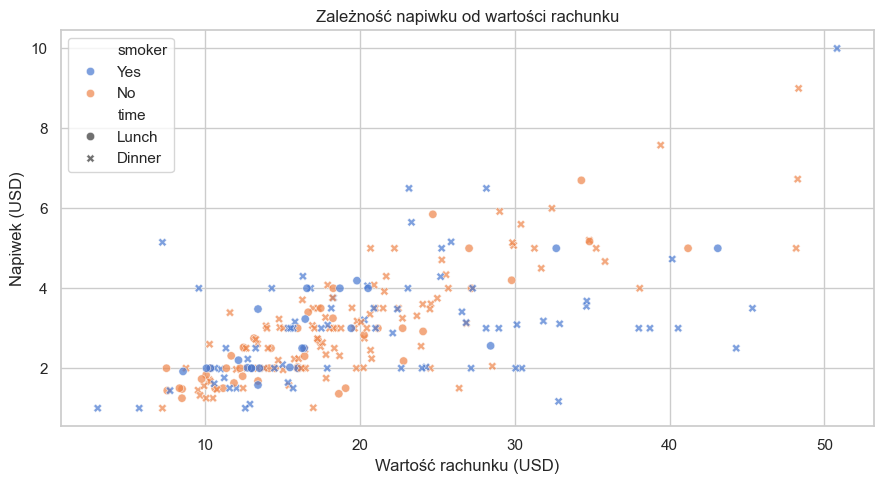

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',
    style='time',
    alpha=0.7,
    ax=ax
)

ax.set_title('Zależność napiwku od wartości rachunku')
ax.set_xlabel('Wartość rachunku (USD)')
ax.set_ylabel('Napiwek (USD)')
plt.tight_layout()
plt.savefig('scatter_rachunek_napiwek.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()

# Zad 2.1

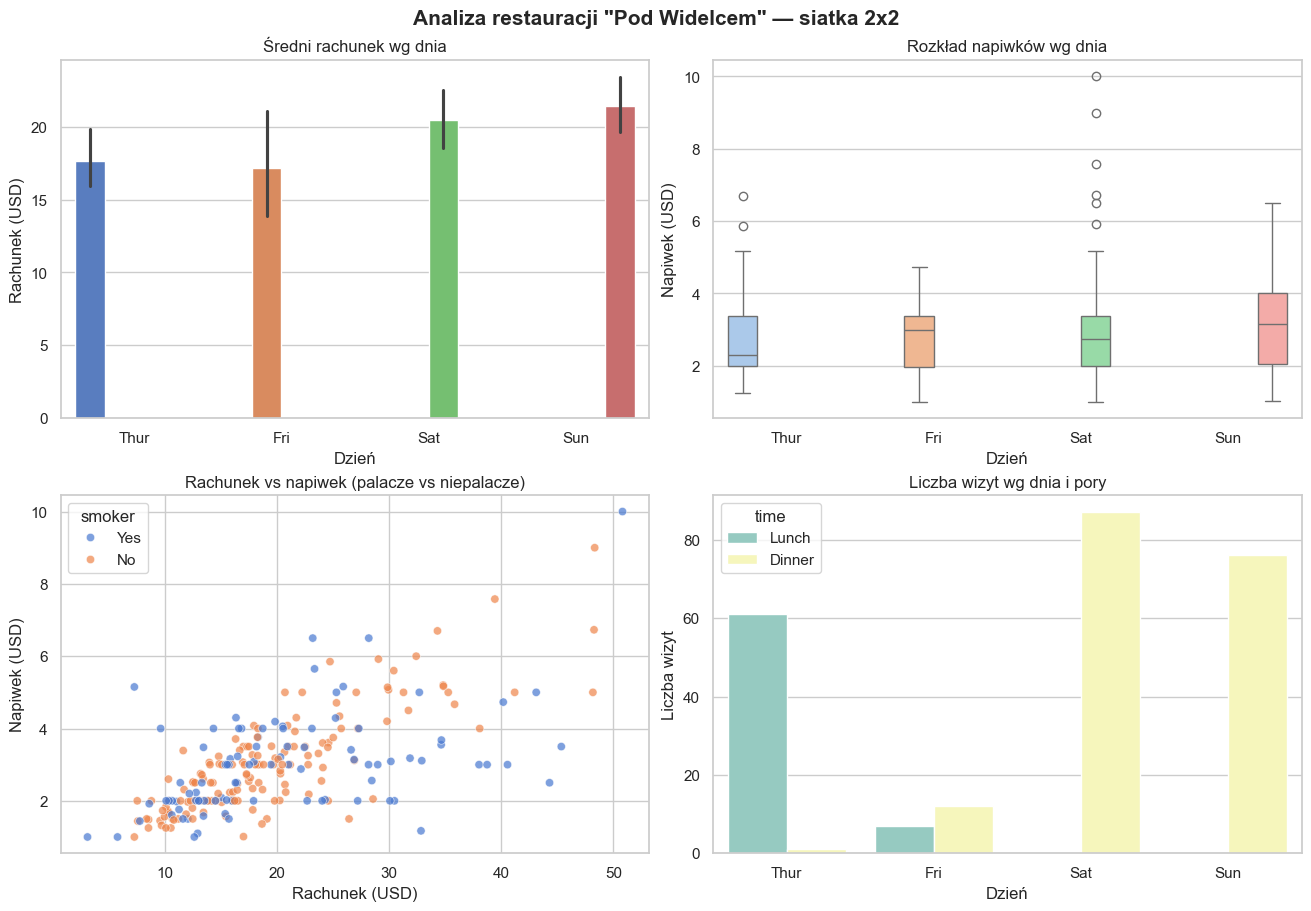

Zapisano: siatka_2x2.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False, ax=axes[0, 0], palette='muted', errorbar=('ci', 95))
axes[0, 0].set_title('Średni rachunek wg dnia')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Rachunek (USD)')
sns.boxplot(data=tips, x='day', y='tip', hue='day', legend=False, ax=axes[0, 1], palette='pastel')
axes[0, 1].set_title('Rozkład napiwków wg dnia')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Napiwek (USD)')
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker', alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Rachunek vs napiwek (palacze vs niepalacze)')
axes[1, 0].set_xlabel('Rachunek (USD)')
axes[1, 0].set_ylabel('Napiwek (USD)')
sns.countplot(data=tips, x='day', hue='time', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Liczba wizyt wg dnia i pory')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Liczba wizyt')
fig.suptitle('Analiza restauracji "Pod Widelcem" — siatka 2x2', fontsize=15, fontweight='bold')
plt.savefig('siatka_2x2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: siatka_2x2.png")

# Zad 2.2

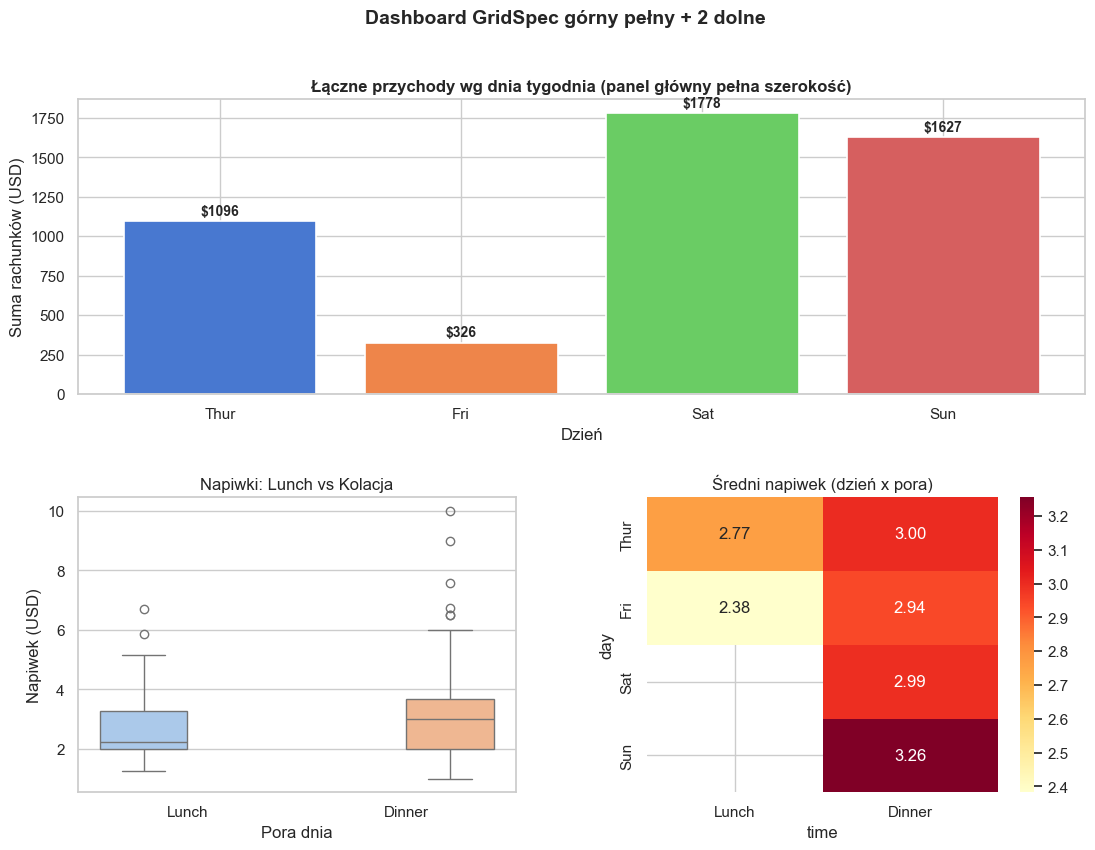

Zapisano: gridspec_dashboard.png


In [8]:
fig = plt.figure(figsize=(13, 9)) 
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
ax_top = fig.add_subplot(gs[0, :])
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index() 
ax_top.bar(
    tips_sum['day'].astype(str), 
    tips_sum['total_bill'], 
    color=sns.color_palette('muted')[:4], 
    edgecolor='white', 
    linewidth=1.2
)

for i, val in enumerate(tips_sum['total_bill']):
    ax_top.text(i, val + 20, f'${val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold') 

ax_top.set_title('Łączne przychody wg dnia tygodnia (panel główny pełna szerokość)', fontsize=12, fontweight='bold') 
ax_top.set_xlabel('Dzień') 
ax_top.set_ylabel('Suma rachunków (USD)') 


ax_bl = fig.add_subplot(gs[1, 0])
sns.boxplot(
    data=tips, 
    x='time', 
    y='tip', 
    hue='time', 
    legend=False, 
    ax=ax_bl, 
    palette='pastel'
) 

ax_bl.set_title('Napiwki: Lunch vs Kolacja')
ax_bl.set_xlabel('Pora dnia') 
ax_bl.set_ylabel('Napiwek (USD)')


ax_br = fig.add_subplot(gs[1, 1]) 
pivot = tips.pivot_table(
    values='tip', 
    index='day', 
    columns='time', 
    aggfunc='mean', 
    observed=True
)

sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax_br) 
ax_br.set_title('Średni napiwek (dzień x pora)') 


fig.suptitle('Dashboard GridSpec górny pełny + 2 dolne', fontsize=14, fontweight='bold')
plt.savefig('gridspec_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white') 
plt.show() 
plt.close() 
print("Zapisano: gridspec_dashboard.png") 

# Zad 2.3

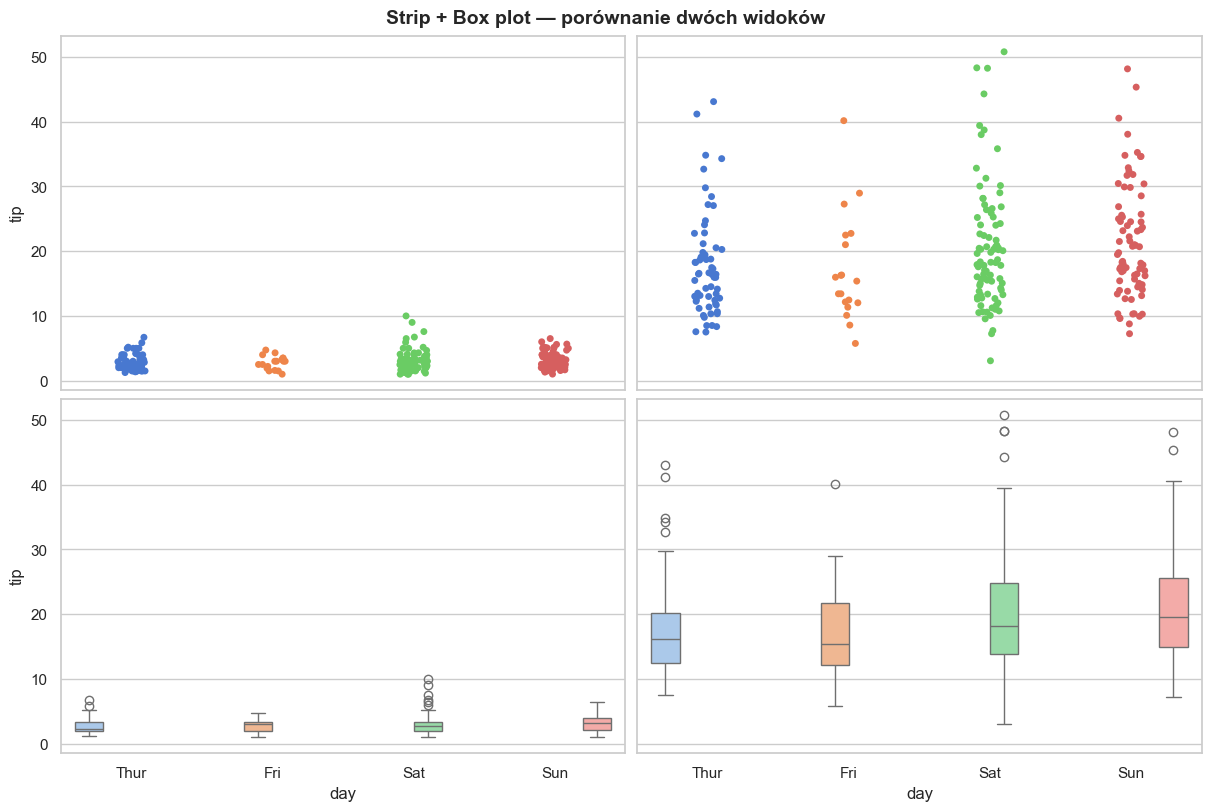

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8),
sharex='col', sharey='row',
constrained_layout=True)
sns.stripplot(data=tips, x='day', y='tip', ax=axes[0, 0], hue='day', legend=False) 
sns.boxplot(data=tips, x='day', y='tip', ax=axes[1, 0], hue='day', legend=False, palette='pastel')
sns.stripplot(data=tips, x='day', y='total_bill', ax=axes[0, 1], hue='day', legend=False) 
sns.boxplot(data=tips, x='day', y='total_bill', ax=axes[1, 1], hue='day', legend=False, palette='pastel')
fig.suptitle('Strip + Box plot — porównanie dwóch widoków',
fontsize=14, fontweight='bold')
plt.savefig('shared_axes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# Zad 3.1

Panel 1 (Główny KPI): Łączne przychody per dzień. Zajmie górną część siatki (2/3 szerokości), aby od razu pokazać, kiedy biznes kręci się najlepiej .  Panel 2 (Struktura): Udział wizyt w poszczególne dni (np. wykres kołowy lub countplot). Pomoże zrozumieć obłożenie lokalu .  Panel 3 (Jakość obsługi): Rozkład napiwków per dzień (boxplot). Pozwoli sprawdzić, czy goście są hojni w dni o największym ruchu .  Panel 4 (Relacje): Macierz korelacji (heatmap). Pokaże, czy istnieje silny związek między rozmiarem stolika a wysokością rachunku .  Panel 5 (Zależności): Zależność rachunek vs napiwek (scatterplot) z podziałem na palaczy. Sprawdzimy, czy styl życia gości wpływa na zyski .  Panel 6 (Podsumowanie): Rozkład rachunków per dzień i pora (violinplot). Zajmie cały dolny wiersz, pokazując pełny obraz finansowy restauracji .  

# Zad 3.2

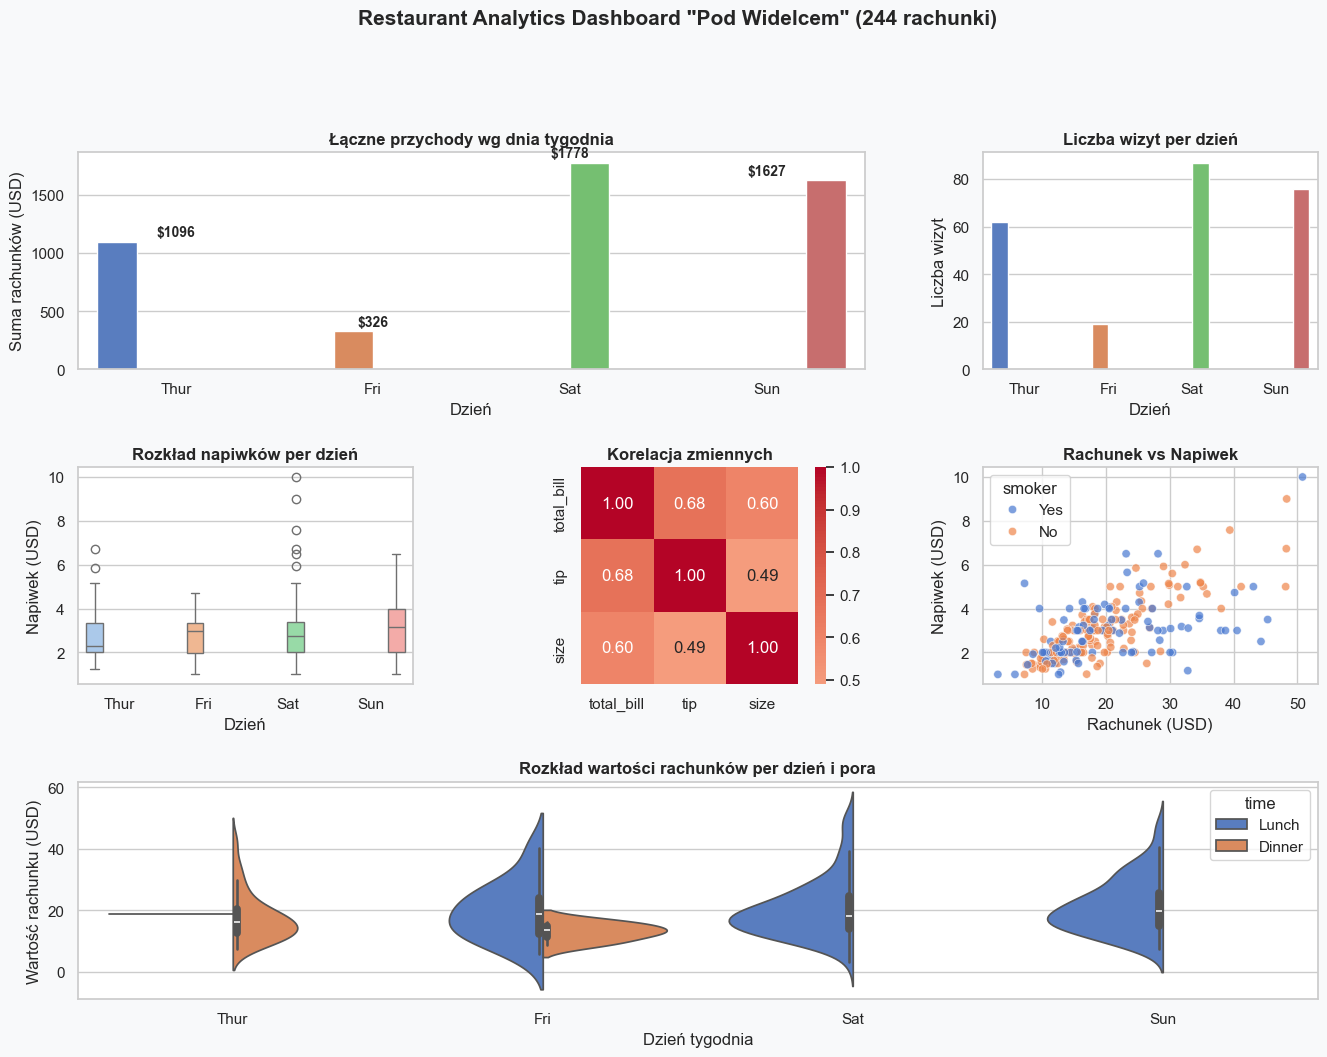

In [10]:
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False, ax=ax1, palette='muted')
for i, val in enumerate(tips_sum['total_bill']):
    ax1.text(i, val + 20, f'${val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Łączne przychody wg dnia tygodnia', fontsize=12, fontweight='bold')
ax1.set_xlabel('Dzień')
ax1.set_ylabel('Suma rachunków (USD)')


ax2 = fig.add_subplot(gs[0, 2])
sns.countplot(data=tips, x='day', hue='day', legend=False, ax=ax2, palette='muted')
ax2.set_title('Liczba wizyt per dzień', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dzień')
ax2.set_ylabel('Liczba wizyt')


ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=tips, x='day', y='tip', hue='day', legend=False, ax=ax3, palette='pastel')
ax3.set_title('Rozkład napiwków per dzień', fontsize=12, fontweight='bold')
ax3.set_xlabel('Dzień')
ax3.set_ylabel('Napiwek (USD)')

ax4 = fig.add_subplot(gs[1, 1])
corr = tips.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax4, square=True)
ax4.set_title('Korelacja zmiennych', fontsize=12, fontweight='bold')

ax5 = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker', alpha=0.7, ax=ax5)
ax5.set_title('Rachunek vs Napiwek', fontsize=12, fontweight='bold')
ax5.set_xlabel('Rachunek (USD)')
ax5.set_ylabel('Napiwek (USD)')


ax6 = fig.add_subplot(gs[2, :])
sns.violinplot(data=tips, x='day', y='total_bill', hue='time', split=True, ax=ax6, palette='muted')
ax6.set_title('Rozkład wartości rachunków per dzień i pora', fontsize=12, fontweight='bold')
ax6.set_xlabel('Dzień tygodnia')
ax6.set_ylabel('Wartość rachunku (USD)')

fig.suptitle('Restaurant Analytics Dashboard "Pod Widelcem" (244 rachunki)', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('dashboard_pod_widelcem.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

# Zad 3.3

 Który dzień jest najbardziej dochodowy?
Najbardziej dochodowym dniem dla restauracji jest sobota, co wyraźnie widać na panelu z łącznymi przychodami (Panel 1). Suma rachunków w ten dzień znacząco przewyższa pozostałe dni tygodnia.

  Czy istnieje korelacja między rachunkiem a napiwkiem?
Tak, istnieje silna dodatnia korelacja między wartością rachunku a wysokością napiwku, wynosząca około 0.68. Oznacza to, że wraz ze wzrostem wydatków klienta na jedzenie, rośnie również kwota zostawianego napiwku.  
  Czy palacze i niepalacze zostawiają różne napiwki?
Na podstawie wykresu rozrzutu (Panel 5) widać, że obie grupy zostawiają napiwki o podobnej strukturze, jednak u palaczy zauważalny jest nieco większy rozrzut wartości. Generalnie trend wzrostowy napiwku względem rachunku jest zachowany w obu grupach.  
 Rekomendacja dla właściciela:
Zalecam zwiększenie obsady kelnerskiej w soboty, ponieważ jest to dzień o najwyższym natężeniu ruchu i najwyższych przychodach. Dodatkowo warto rozważyć wprowadzenie specjalnych ofert lunchowych w czwartki, gdyż jest to jedyny dzień tygodnia, w którym pora lunchu dominuje nad kolacją. 

# Zad 4.1

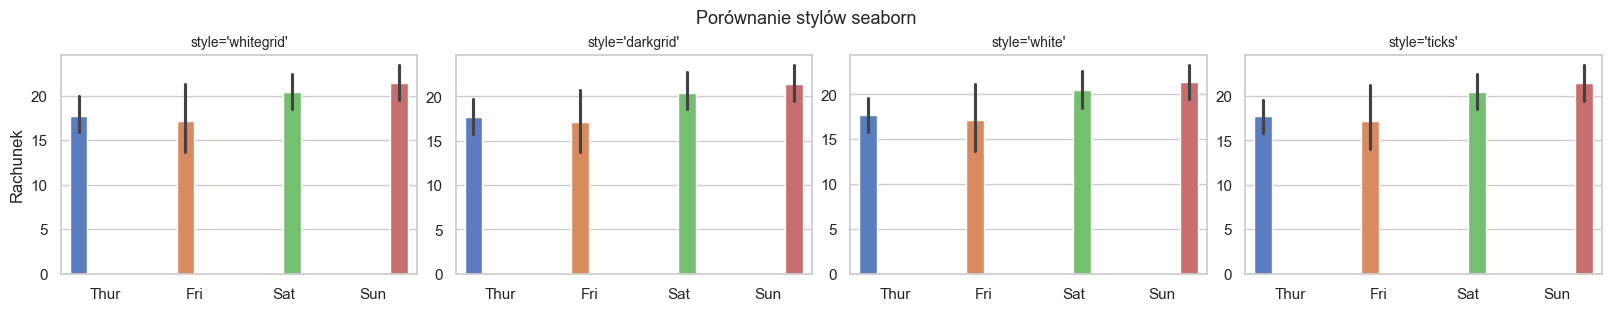

In [11]:
styles = ['whitegrid', 'darkgrid', 'white', 'ticks']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), constrained_layout=True)

for ax, style in zip(axes, styles):
    with sns.axes_style(style):
        sns.barplot(
            data=tips, 
            x='day', 
            y='total_bill', 
            hue='day', 
            legend=False,
            ax=ax, 
            palette='muted'
        )
        ax.set_title(f"style='{style}'", fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Rachunek' if ax is axes[0] else '')

fig.suptitle('Porównanie stylów seaborn', fontsize=13)
plt.savefig('porownanie_stylow.png', dpi=150, bbox_inches='tight', facecolor='white')

plt.show()
plt.close()

#Do prezentacji zarządczej (slajdy): Najlepszy będzie styl darkgrid lub whitegrid. Siatka ułatwia szybkie odczytanie wartości w dynamicznym środowisku prezentacji.  
#Do publikacji naukowej (papier): Wybiera się styl white lub ticks. Są one najbardziej minimalistyczne, nie marnują tuszu i najlepiej wyglądają na białej stronie dokumentu.

# Zad 4.2

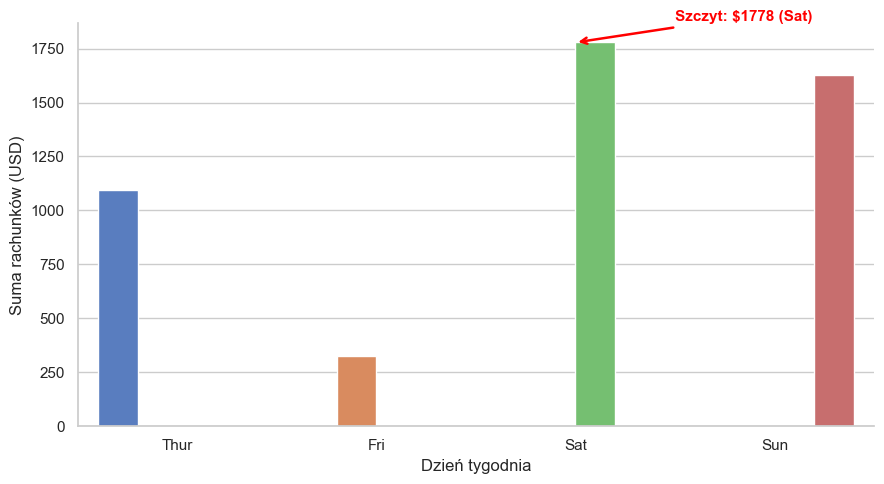

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index() 


sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False, ax=ax, palette='muted')


max_idx = tips_sum['total_bill'].idxmax() 
max_day = tips_sum.loc[max_idx, 'day'] 
max_val = tips_sum.loc[max_idx, 'total_bill'] 

ax.annotate(
    f'Szczyt: ${max_val:.0f} ({max_day})', 
    xy=(max_idx, max_val),                
    xytext=(max_idx + 0.5, max_val + 100), 
    arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
    fontsize=11, color='red', fontweight='bold' 
)


ax.set_xlabel('Dzień tygodnia') 
ax.set_ylabel('Suma rachunków (USD)') 
sns.despine() 

plt.tight_layout() 
plt.savefig('szczyt_przychodow.png', dpi=150, bbox_inches='tight', facecolor='white') 
plt.show()
plt.close()